<a href="https://colab.research.google.com/github/Tamannapanwar17/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Understanding

## Define the Problem:

Credit Card Fraud Detection

Credit card fraud is a major challenge for banks and financial institutions, leading to significant financial losses each year. Fraudulent transactions are rare compared to legitimate ones, making fraud detection a highly imbalanced binary classification problem.

The objective of this project is to develop a machine learning model capable of accurately identifying fraudulent transactions while minimizing false alarms. Since fraudulent transactions represent only a very small fraction of the dataset, special techniques such as SMOTE will be used to address class imbalance.

The final model will be optimized and deployed as a Streamlit web application for real-time fraud prediction.

# Data Collection

In [1]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv.zip to creditcard.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile('creditcard.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [3]:
import os

os.listdir()

['.config', 'creditcard.csv', 'creditcard.csv.zip', 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

# Data Understanding

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


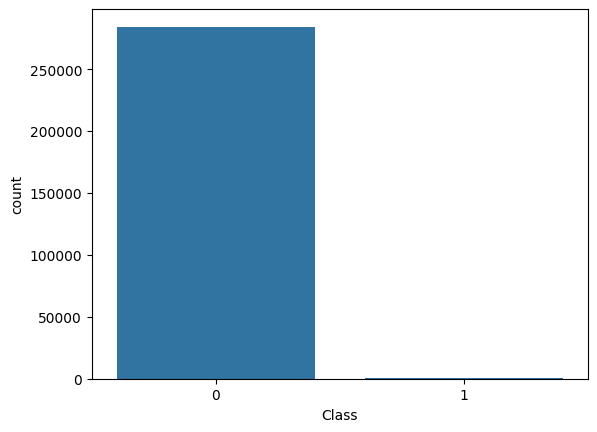

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.show()

In [11]:
print(df['Class'].value_counts(normalize=True)*100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


#Class	Percentage
#####Legitimate	99.83%
#####Fraud	0.17%

In [12]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


######**Count (284807):** No missing values in Amount.
#####**Mean (88.35)**: Average transaction amount.
#####**Median (22.00)**: Half of transactions are below 22.
#####**Max (25691.16)**: Very large transactions exist.
#####**Standard deviation (250.12)**: High variability in transaction amounts.

The mean being much higher than the median suggests the distribution is right-skewed because of a few very large transactions.

In [13]:
df.duplicated().sum()

np.int64(1081)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(283726, 31)

In [17]:
df["Class"].value_counts()

,count
Class,
0,283253
1,473


In [18]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 

# Exploratory Data Analysis (EDA)

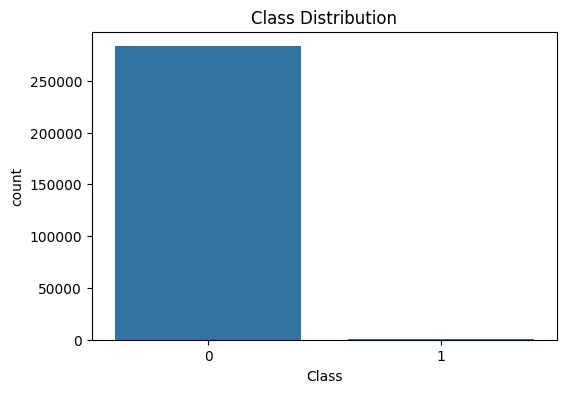

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")

plt.show()

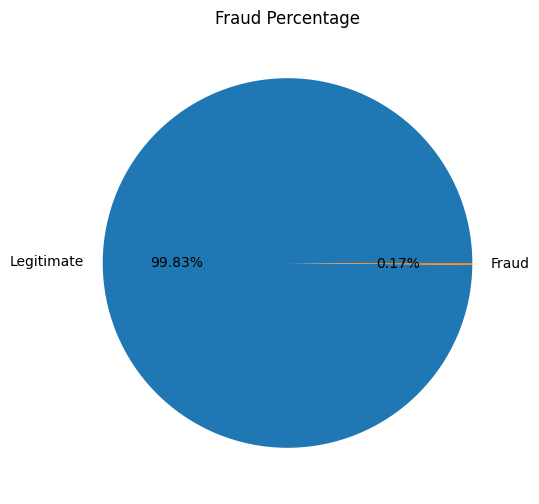

In [22]:
fraud=df["Class"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    fraud,
    labels=["Legitimate","Fraud"],
    autopct="%1.2f%%"
)

plt.title("Fraud Percentage")

plt.show()

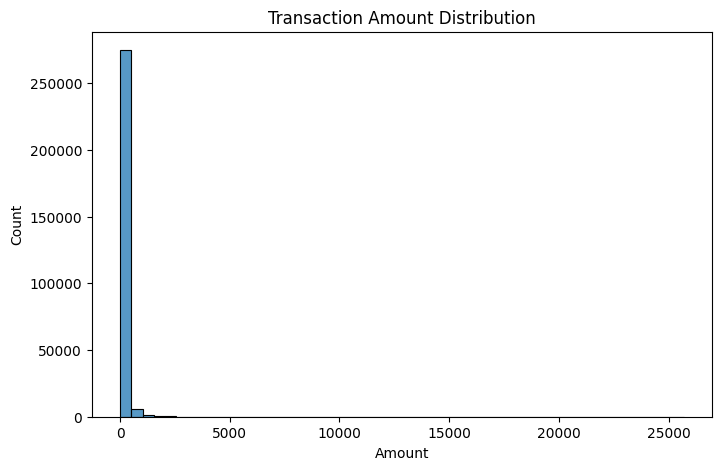

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"],bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

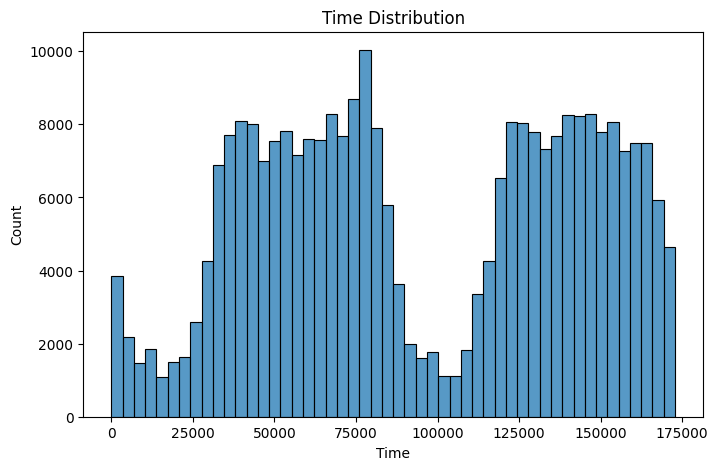

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Time"],bins=50)

plt.title("Time Distribution")

plt.show()

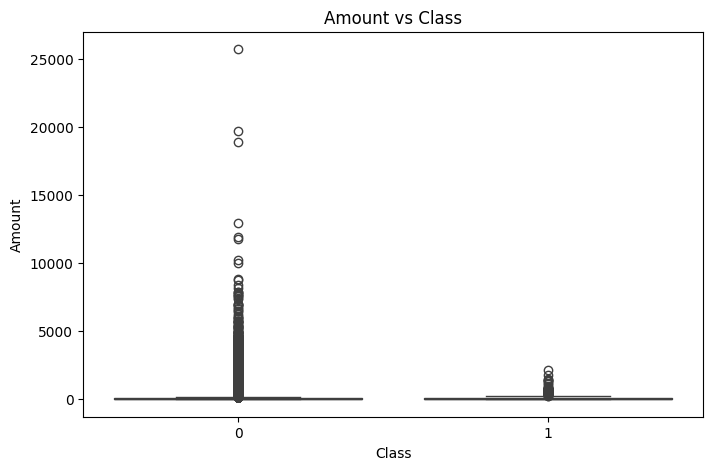

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.title("Amount vs Class")

plt.show()

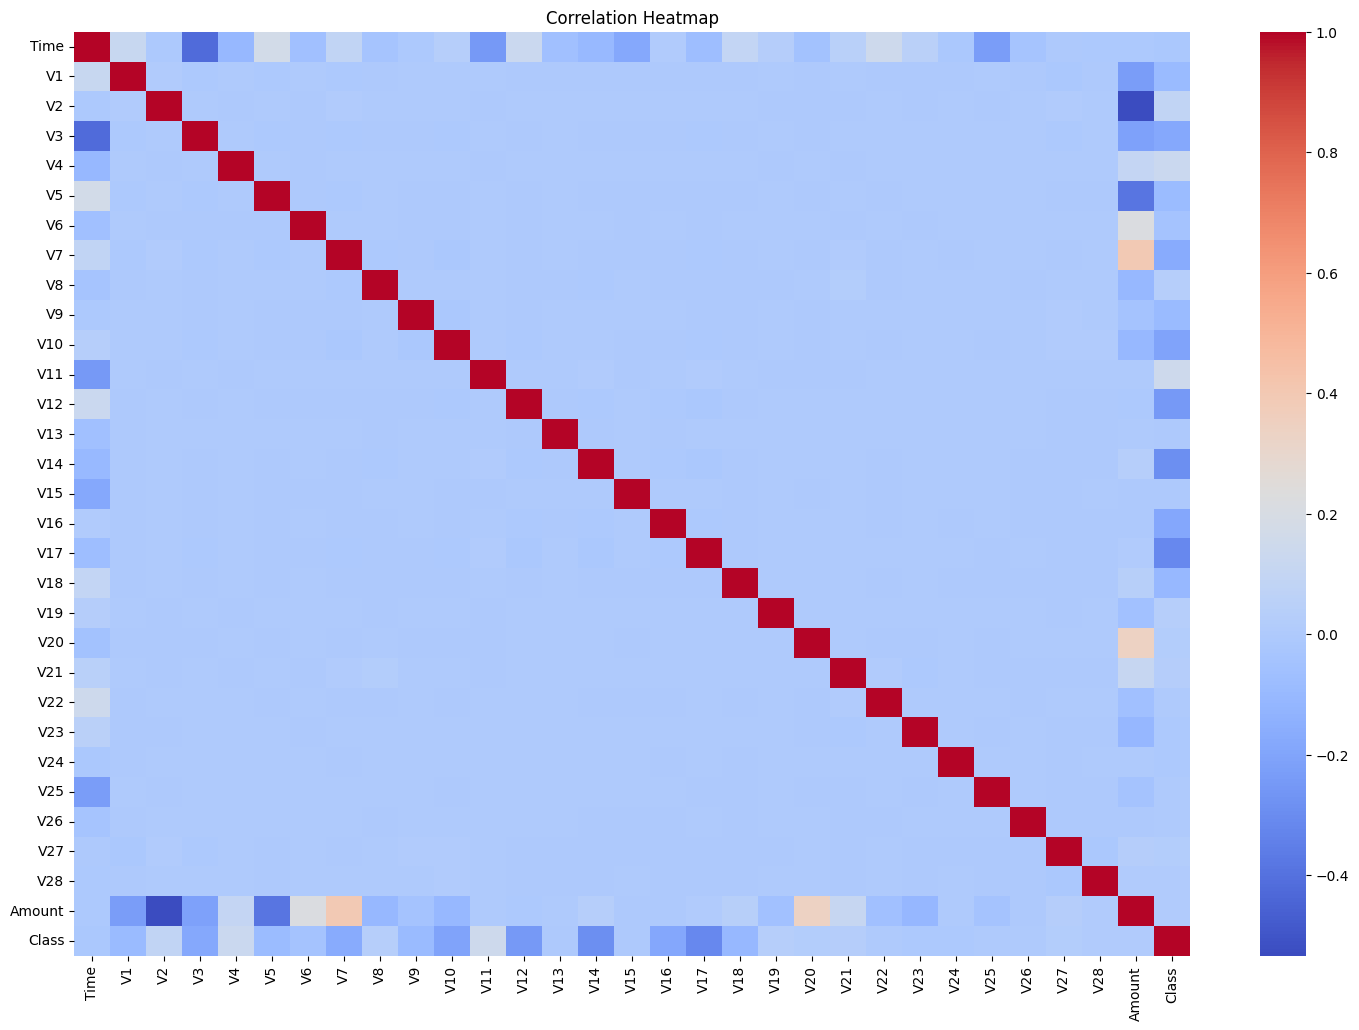

In [26]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

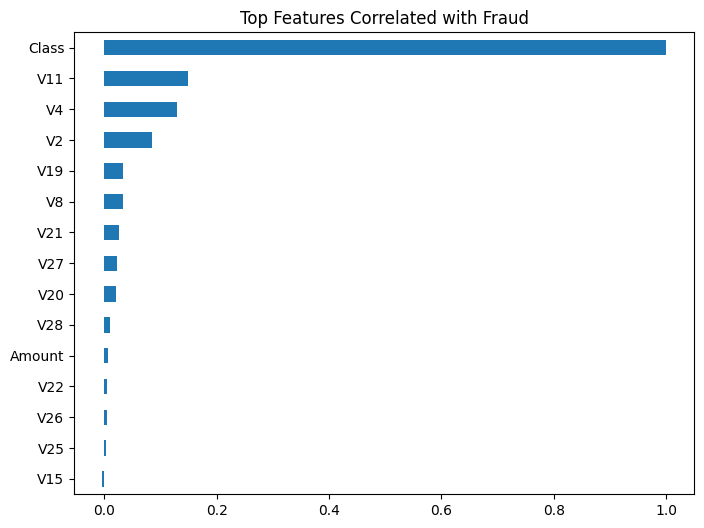

In [27]:
corr=df.corr()["Class"].sort_values()

corr.tail(15).plot(kind="barh",figsize=(8,6))

plt.title("Top Features Correlated with Fraud")

plt.show()

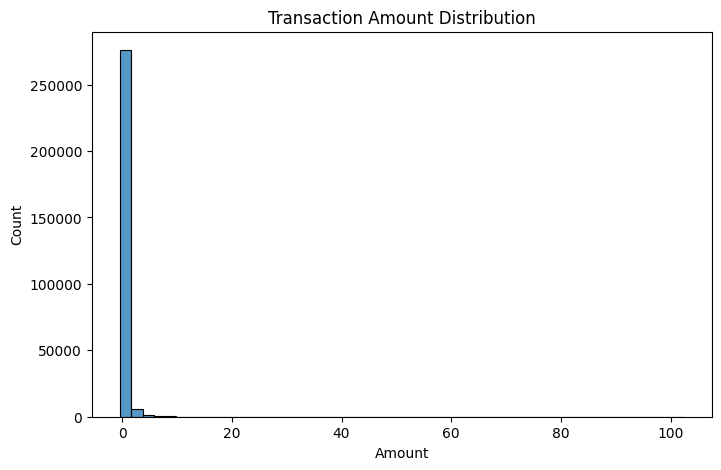

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.show()

# Data Preprocessing

In [28]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df["Amount"]=scaler.fit_transform(df[["Amount"]])


In [29]:
df.drop('Time', axis=1, inplace=True)

In [30]:
X = df.drop('Class', axis=1)
y = df['Class']

# Train - Test Split

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print(y_train.value_counts())
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


# Handle Imbalanced Data

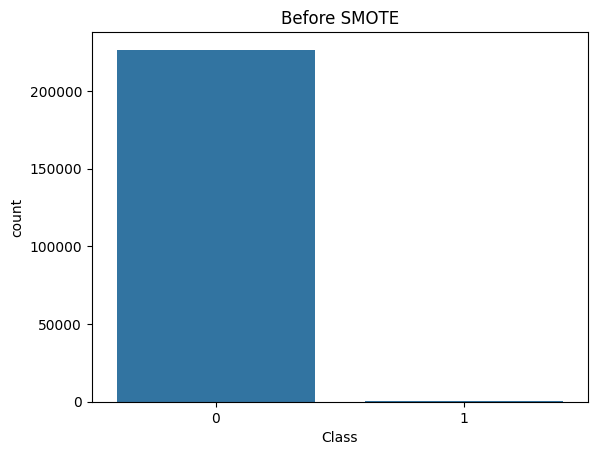

In [33]:
sns.countplot(x=y_train)

plt.title("Before SMOTE")

plt.show()

In [34]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)

X_train_smote,y_train_smote=smote.fit_resample(
    X_train,
    y_train
)

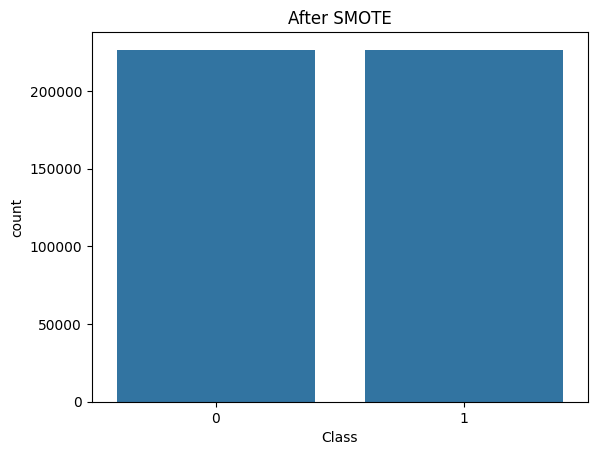

In [35]:
sns.countplot(x=y_train_smote)

plt.title("After SMOTE")

plt.show()

# Baseline Models

In [36]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [40]:
from xgboost import XGBClassifier

xgb=XGBClassifier(random_state=42)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

# Model Evaluation

In [41]:
from sklearn.metrics import classification_report

pred=rf.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.74      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



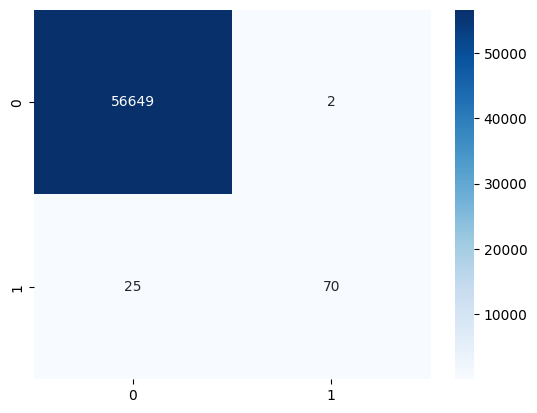

In [42]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

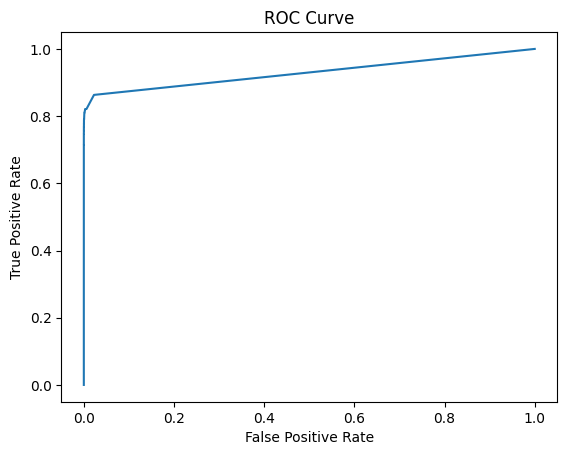

In [43]:
from sklearn.metrics import roc_curve

prob=rf.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

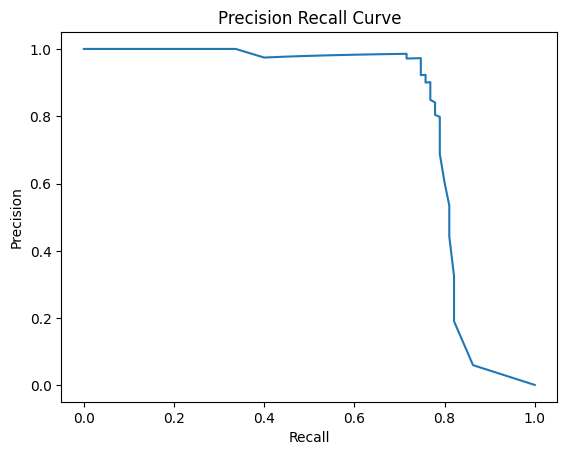

In [44]:
from sklearn.metrics import precision_recall_curve

precision,recall,_=precision_recall_curve(
    y_test,
    prob
)

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

In [46]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.9 MB/s eta 0:00:00


In [49]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [50]:
import optuna

from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [51]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [52]:
def objective(trial):

    model_name = trial.suggest_categorical(
        "model",
        [
            "Logistic Regression",
            "Decision Tree",
            "Random Forest",
            "XGBoost"
        ]
    )

    if model_name == "Logistic Regression":

        model = LogisticRegression(

            C=trial.suggest_float("C",0.001,100,log=True),

            solver=trial.suggest_categorical(
                "solver",
                ["liblinear","lbfgs"]
            ),

            max_iter=1000,

            random_state=42

        )

    elif model_name == "Decision Tree":

        model = DecisionTreeClassifier(

            criterion=trial.suggest_categorical(
                "criterion",
                ["gini","entropy"]
            ),

            max_depth=trial.suggest_int(
                "max_depth",
                3,
                30
            ),

            min_samples_split=trial.suggest_int(
                "min_samples_split",
                2,
                20
            ),

            min_samples_leaf=trial.suggest_int(
                "min_samples_leaf",
                1,
                10
            ),

            random_state=42

        )

    elif model_name == "Random Forest":

        model = RandomForestClassifier(

            n_estimators=trial.suggest_int(
                "n_estimators",
                100,
                500
            ),

            max_depth=trial.suggest_int(
                "max_depth",
                5,
                30
            ),

            min_samples_split=trial.suggest_int(
                "min_samples_split",
                2,
                20
            ),

            min_samples_leaf=trial.suggest_int(
                "min_samples_leaf",
                1,
                10
            ),

            max_features=trial.suggest_categorical(
                "max_features",
                ["sqrt","log2"]
            ),

            random_state=42

        )

    else:

        model = XGBClassifier(

            n_estimators=trial.suggest_int(
                "n_estimators",
                100,
                500
            ),

            learning_rate=trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True
            ),

            max_depth=trial.suggest_int(
                "max_depth",
                3,
                12
            ),

            subsample=trial.suggest_float(
                "subsample",
                0.6,
                1.0
            ),

            colsample_bytree=trial.suggest_float(
                "colsample_bytree",
                0.6,
                1.0
            ),

            gamma=trial.suggest_float(
                "gamma",
                0,
                5
            ),

            eval_metric="logloss",

            random_state=42

        )

    score = cross_val_score(

        model,

        X_train_smote,

        y_train_smote,

        cv=cv,

        scoring="f1"

    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=50
)

[I 2026-07-12 05:57:16,486] A new study created in memory with name: no-name-9bcd9ba7-02b2-4e32-a2a1-42f92fce7aa9


In [ ]:
print("Best Model:")
print(study.best_params["model"])